# A — Préparation des données & feature engineering (EventZilla)

**Rôle** : transformer le DW en matrices **numériques** réutilisables par **C, D, E, F**. Aucun modèle final ici.

Concrètement, ce carnet **aligne** les extractions SQL avec le barème **A** : traçabilité des colonnes (lineage), figures d’exploration, et **artefacts** (`parquet`, `npy`, `joblib`) que les notebooks suivants rechargent tels quels. La sélection de variables (étape 4) reste **documentaire** : elle n’écrase pas la liste complète exportée en étape 5, ce qui préserve la **reproductibilité** et la **comparabilité** entre tâches ML.

**Grille A** : manquants (imputation médiane prévue), outliers **documentés** (pas de suppression systématique), encodage catégoriel, **StandardScaler** / **MinMaxScaler**, illustration **filter · wrapper · embedded** (JSON sans tronquer les exports).

| # | Section | Livrables |
|---|---------|-----------|
| 1 | Connexion DW | Alignement SSMS |
| 2 | Extraction large | `dw_financial_wide.parquet`, `A_dw_columns_lineage.json` |
| 3 | `X_raw` + EDA | `A_encoding_*`, `A_xraw_column_lineage.json`, figures `A_*.png` |
| 4 | Sélection (démo) | `A_feature_selection_summary.json` |
| 5 | Imputation + scale | `*.joblib`, `X_*.npy`, `features_matrix.*` |

**B (modèles)** : **`06_B_comprehension_modeles.ipynb`** (intuition, paramètres, hypothèses, limites, justification des paires) ; rappels par tâche dans **01_E–04_F**.

**Ordre d’exécution** : lancer **00_A** avant **01_E → 04_F** pour que les matrices et scalers correspondent aux chemins attendus dans le code.

Références : `EventZilla_Dashboards_Improved.pdf`, `docs/eventzilla/EventZilla_Dashboards_KPIs_Objectifs.md`


## Référence critère A — alignement mail de validation

| Thème | Ce notebook |
|-------|-------------|
| Manquants | Diagnostic + imputation **médiane** (étape 5) |
| Outliers | Boxplots, taux IQR — **pas de censure** par défaut |
| Encodage | `get_dummies` sur catégorielles DW |
| Scaling | `StandardScaler` (référence), `MinMaxScaler` |
| Sélection | Filter / RFE / LassoCV → JSON **documentaire** |

Chaque ligne du tableau correspond à une **preuve** attendue dans un rapport de validation : soit une **figure** (distributions, corrélations, IQR), soit un **fichier** traçable (`*.json`, `*.joblib`). L’objectif n’est pas de « nettoyer agressivement » le DW, mais de **documenter** les choix (médiane, pas de drop systématique des extrêmes) pour que le lecteur comprenne ce qui entre dans les modèles.

**Fichiers** : voir tableau dans l’intro ( `ML/processed/` ).

**Environnement** : `EVENTZILLA_ML_SQL_ONLY=1` force le DW ; `ML/ml_paths.py`.


## 1. Connexion au Data Warehouse

**À valider** : `SQL_SERVER`, `DATABASE_DW`, test `SELECT DB_NAME()` — même cible que SSMS.

**Si échec** : service SQL, ODBC, variables `EVENTZILLA_SQL_*`.


In [6]:
# --- Connexion au Data Warehouse ---
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

from ML.ml_paths import (
    DATABASE_DW,
    SQL_SERVER,
    SQL_DRIVER,
    SQL_PORT,
    build_windows_auth_uri,
    get_sql_engine,
    ml_sql_only,
    read_dw_sql,
    sql_engine_init_error,
)

print("=" * 62)
print(" EVENTZILLA — Connexion DW (équivalent accès SSMS)")
print("=" * 62)
print("  Serveur SQL      :", SQL_SERVER + (":" + str(SQL_PORT) if SQL_PORT else ""))
print("  Base DW cible    :", DATABASE_DW)
print("  Driver ODBC      :", SQL_DRIVER)
print("  Mode DW seul     :", ml_sql_only(), "(EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)")
try:
    _uri = build_windows_auth_uri()
    print("  Chaîne (extrait) :", (_uri[:88] + "…") if len(_uri) > 88 else _uri)
except Exception as _uerr:
    print("  Chaîne URI       : erreur", _uerr)
_eng = get_sql_engine()
if _eng is not None:
    try:
        _chk = read_dw_sql(
            "SELECT DB_NAME() AS base_active, CAST(SERVERPROPERTY('ServerName') AS NVARCHAR(128)) AS serveur",
            _eng,
        )
        print("  Test SQL         : OK — même base que sous SSMS si base_active =", DATABASE_DW)
        print(_chk.to_string(index=False))
    except Exception as _qerr:
        print("  Test SQL         : ÉCHEC —", _qerr)
else:
    print("  Engine           : ABSENT —", sql_engine_init_error() or "voir pip sqlalchemy pyodbc")
print("=" * 62)


 EVENTZILLA — Connexion DW (équivalent accès SSMS)
  Serveur SQL      : ASUSRANIM
  Base DW cible    : DW_eventzella
  Driver ODBC      : ODBC Driver 17 for SQL Server
  Mode DW seul     : True (EVENTZILLA_ML_SQL_ONLY=1 → pas de Excel/CSV)
  Chaîne (extrait) : mssql+pyodbc://@ASUSRANIM/DW_eventzella?driver=ODBC+Driver+17+for+SQL+Server&trusted_con…
  Test SQL         : OK — même base que sous SSMS si base_active = DW_eventzella
  base_active   serveur
DW_eventzella AsusRanim


## 2. Extraction du jeu financier large

**Sortie** : `df_ml` → `dw_financial_wide.parquet` + traçabilité colonne → table (`A_dw_columns_lineage.json`).

**Lecture** : chaque colonne du Parquet doit être traçable vers `Fact_*` / `Dim_*`.


In [7]:
# --- Extraction DW → Parquet ---
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT != REPO_ROOT.parent:
    if (REPO_ROOT / "ML" / "ml_paths.py").is_file():
        break
    REPO_ROOT = REPO_ROOT.parent
if not (REPO_ROOT / "ML" / "ml_paths.py").is_file():
    raise FileNotFoundError("Ouvrez Jupyter depuis la racine du dépôt (dossier contenant ML/)")
sys.path.insert(0, str(REPO_ROOT))

import json
import warnings
import numpy as np
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import joblib

warnings.filterwarnings("ignore")

# Noyau Jupyter : retirer les vieux modules ML pour forcer la relecture depuis le disque.
for _m in ("ML.dw_lineage", "ML.schema_eventzilla"):
    sys.modules.pop(_m, None)

from ML.ml_paths import (
    ML_PROCESSED,
    SQL_SERVER,
    backup_paths_status,
    ensure_processed_dirs,
    get_sql_engine,
    ml_sql_only,
    read_dw_sql,
    sql_engine_init_error,
    DATABASE_DW,
)
from ML.schema_eventzilla import (
    SQL_LIST_TABLES,
    SQL_ML_FINANCIAL_WIDE,
    build_sql_ml_financial_wide,
    infer_column_dw_source,
    ml_financial_wide_sql_tables_lineage,
)

ensure_processed_dirs()
print("[Extraction] 🗄️ Backups FilesMachine/DB :", backup_paths_status())

engine = get_sql_engine()
df_ml = None
if engine is None and ml_sql_only():
    raise RuntimeError("[Extraction] Connexion SQL obligatoire (EVENTZILLA_ML_SQL_ONLY=1).")
if engine is not None:
    try:
        tables = read_dw_sql(SQL_LIST_TABLES, engine)
        print("[Extraction] Tables DW (aperçu):")
        print(tables.head(25))
        try:
            q_fin = build_sql_ml_financial_wide(engine)
            df_ml = read_dw_sql(q_fin, engine)
            print("[Extraction] Chargement DW : requête financière adaptée (jointures id_date → id_date_SK, etc.).")
        except Exception as e_dyn:
            print("[Extraction] Requête dynamique indisponible, essai requête statique :", e_dyn)
            df_ml = read_dw_sql(SQL_ML_FINANCIAL_WIDE, engine)
        if df_ml is not None and len(df_ml) == 0:
            if ml_sql_only():
                raise RuntimeError("[Extraction] 0 ligne depuis le DW — vérifiez les faits peuplés et id_date = id_date_SK.")
            print("[Extraction] 0 ligne DW — bascule données locales (ML_SQL_ONLY=0).")
            df_ml = None
        if df_ml is not None:
            print("[Extraction] Jeu large financier (lignes, cols) :", df_ml.shape)
            df_ml.to_parquet(ML_PROCESSED / "dw_financial_wide.parquet", index=False)
            print("[Extraction] ✅ Parquet sauvegardé : dw_financial_wide.parquet")
            print("\n" + "=" * 62)
            print(" TABLES DW & COLONNES — jeu `df_ml` (vos données)")
            print("=" * 62)
            print(ml_financial_wide_sql_tables_lineage())
            print("\nListe des colonnes dans CET extrait (nom Python → table DW probable) :")
            for _cn in df_ml.columns:
                print(f"  • {_cn!r}  →  {infer_column_dw_source(_cn)}")
            try:
                _lin = {
                    "columns": list(df_ml.columns),
                    "lineage_per_column": {c: infer_column_dw_source(c) for c in df_ml.columns},
                }
                with open(ML_PROCESSED / "A_dw_columns_lineage.json", "w", encoding="utf-8") as _lf:
                    json.dump(_lin, _lf, indent=2, ensure_ascii=False)
                print("\n[Extraction] Traçabilité sauvegardée : A_dw_columns_lineage.json")
            except Exception as _el:
                print("[Extraction] Sauvegarde lineage :", _el)
            print("=" * 62 + "\n")
    except Exception as e:
        if ml_sql_only():
            raise RuntimeError("[Extraction] Lecture DW requise : " + str(e)) from e
        print("[Extraction] Échec lecture DW — repli fichiers locaux si ML_SQL_ONLY=0 :", e)
        df_ml = None
else:
    print("[Extraction] Pas d’engine SQL.")
    _err = sql_engine_init_error()
    if _err:
        print("[Extraction] Détail technique :", _err)
    if not ml_sql_only():
        print("[Extraction] Avec ML_SQL_ONLY=0 : repli Excel possible. Sinon : pip sqlalchemy pyodbc, python ML/scripts/run_test_sql_connection.py.")


[Extraction] 🗄️ Backups FilesMachine/DB : {'DW_Eventzilla': True, 'SA_eventzilla': True}
[Extraction] Tables DW (aperçu):
   TABLE_SCHEMA                   TABLE_NAME
0           dbo            DimBenchmarkPrice
1           dbo               DimBeneficiary
2           dbo                 DimComplaint
3           dbo                      DimDate
4           dbo                     DimEvent
5           dbo                  DimFeedback
6           dbo                  DimProvider
7           dbo               DimReservation
8           dbo           DimServiceCategory
9           dbo                  DimVisitors
10          dbo       fact_performance_comm2
11          dbo  Fact_PerformanceCommerciale
12          dbo   Fact_RentabiliteFinanciere
13          dbo      Fact_SatisfactionClient
14          dbo                  sysdiagrams
[Extraction] Chargement DW : requête financière adaptée (jointures id_date → id_date_SK, etc.).
[Extraction] Jeu large financier (lignes, cols) : (20142, 16)


## 3. Matrice `X_raw`, encodage, EDA

**But** : 100 % numérique (numériques DW + one-hot), fichiers de lineage.

**Interprétation des figures (après la cellule code)** :

| Figure | Lecture |
|--------|---------|
| `A_missing_percent_bar` | Où l’imputation médiane pèse le plus |
| `A_boxplots_numeric` | Asymétrie / extrêmes des montants |
| `A_correlation_heatmap` | Redondance (ex. temps : mois vs trimestre) |
| `A_iqr_outlier_rate` | Part « au-delà des moustaches » — info, pas filtre |



[EDA] Source DW — matrice après encodage : (20142, 133) | numériques : 13 | colonnes one-hot : 120

 DÉTAIL — One-hot encoding (noms réels `df_ml` → tables DW)
Jeu large ML `df_ml` / `dw_financial_wide` provient typiquement de :
  • Fait rentabilité : [dbo].[Fact_RentabiliteFinanciere] (alias SQL **f**)
  • Calendrier      : [dbo].[DimDate] (alias **d**) — jointure f.id_date = d.id_date_SK
  • Réservations    : [dbo].[DimReservation] (alias **r**) lorsque la jointure FK ou événement / pont est résolue
(sinon le SELECT peut se limiter à fait + date).

• Colonnes **catégorielles sources** (avant dummies) → table DW :
    'full_date'  →  [dbo].[DimDate]

• Colonnes **créées** par get_dummies(drop_first=True) — modalités 0/1 → table d’origine :
    full_date_2022-01-02                                  [dbo].[DimDate] (modalité 0/1 issue de la colonne full_date)
    full_date_2022-01-03                                  [dbo].[DimDate] (modalité 0/1 issue de la colonne full_date)
    full_da

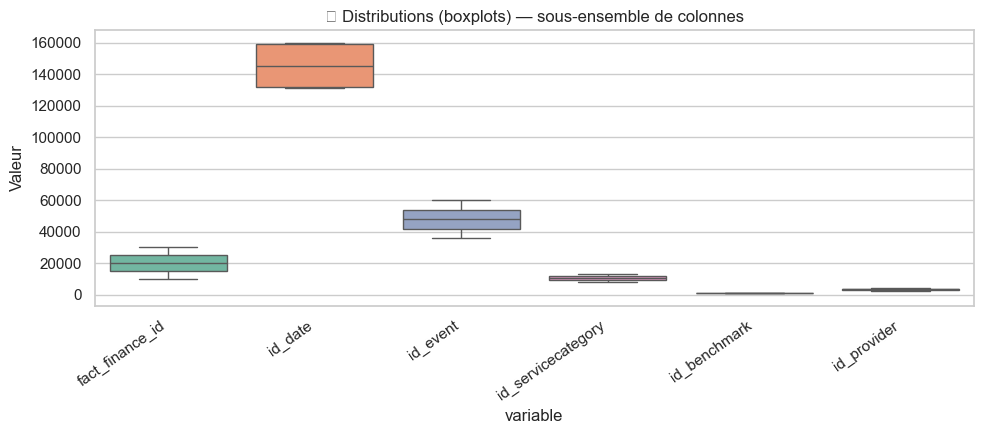

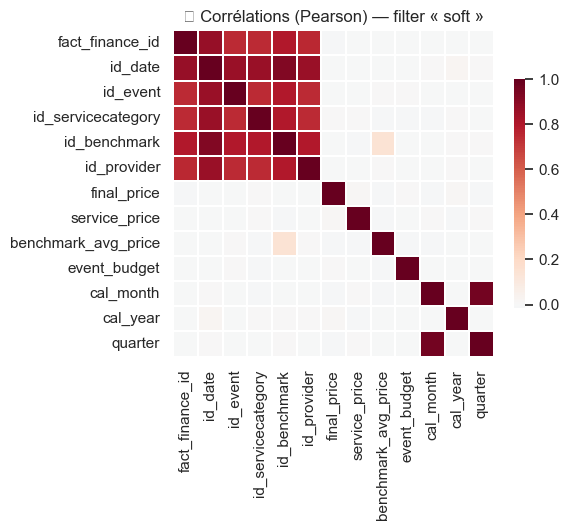

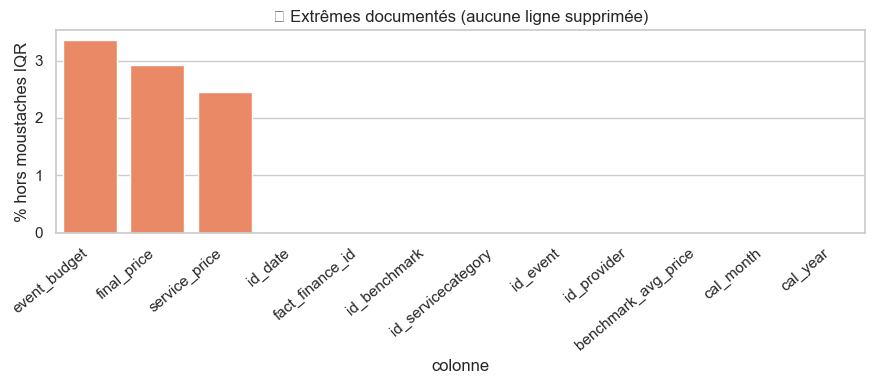

[EDA] ✅ Sauvegardé : X_raw_numeric.npy


In [8]:
# --- Matrice X_raw + figures EDA ---
%matplotlib inline
import json
import sys
for _m in ("ML.dw_lineage", "ML.schema_eventzilla"):
    sys.modules.pop(_m, None)
from ML.csv_local_fallback import csv_search_roots_hint, load_numeric_from_local_csvs
from ML.ml_paths import ML_PROCESSED, ml_sql_only
from ML.schema_eventzilla import infer_column_dw_source, ml_financial_wide_sql_tables_lineage
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


def _build_feature_matrix_from_df(df: pd.DataFrame):
    """Retourne (X_raw, meta) avec le détail one-hot pour la documentation."""
    meta = {
        "numeric_columns": list(df.select_dtypes(include=[np.number]).columns),
        "categorical_source_columns": [],
        "one_hot_columns": [],
        "one_hot_truncated": False,
        "one_hot_dropped_first_per_cat": True,
    }
    num = df.select_dtypes(include=[np.number]).copy()
    cat = df.select_dtypes(include=["object", "string", "category"]).copy()
    meta["categorical_source_columns"] = list(cat.columns)
    for c in cat.columns:
        try:
            cat[c] = cat[c].astype("string")
        except Exception:
            pass
    if cat.shape[1] == 0:
        return num, meta
    enc = pd.get_dummies(cat, drop_first=True, dummy_na=False)
    if enc.shape[1] > 120:
        enc = enc.iloc[:, :120]
        meta["one_hot_truncated"] = True
    meta["one_hot_columns"] = list(enc.columns)
    out = pd.concat([num.reset_index(drop=True), enc.reset_index(drop=True)], axis=1)
    return out, meta


encoding_meta = None
if df_ml is not None:
    X_raw, encoding_meta = _build_feature_matrix_from_df(df_ml)
    n_num = len(encoding_meta["numeric_columns"])
    n_oh = len(encoding_meta["one_hot_columns"])
    print("[EDA] Source DW — matrice après encodage :", X_raw.shape, "| numériques :", n_num, "| colonnes one-hot :", n_oh)
    print("\n" + "=" * 62)
    print(" DÉTAIL — One-hot encoding (noms réels `df_ml` → tables DW)")
    print("=" * 62)
    print(ml_financial_wide_sql_tables_lineage())
    print("\n• Colonnes **catégorielles sources** (avant dummies) → table DW :")
    if encoding_meta["categorical_source_columns"]:
        for _cs in encoding_meta["categorical_source_columns"]:
            print(f"    {_cs!r}  →  {infer_column_dw_source(_cs)}")
    else:
        print("    (aucune)")
    print("\n• Colonnes **créées** par get_dummies(drop_first=True) — modalités 0/1 → table d’origine :")
    if encoding_meta["one_hot_columns"]:
        ohc = encoding_meta["one_hot_columns"]
        for _dc in ohc[:45]:
            print(f"    {str(_dc)[:52]:52s}  {infer_column_dw_source(_dc)}")
        if len(ohc) > 45:
            print(f"    … +{len(ohc) - 45} autres dummies (liste complète dans le JSON)")
        if encoding_meta["one_hot_truncated"]:
            print("  ⚠️ Plus de 120 dummies générées : conservation des 120 premières colonnes dummies (limite notebook).")
    else:
        print("    (aucune)")
    print("\n• Colonnes **numériques natives** (inchangées, non one-hot) → table DW :")
    for _nc in encoding_meta["numeric_columns"]:
        print(f"    {_nc!r}  →  {infer_column_dw_source(_nc)}")
    print("=" * 62 + "\n")
    try:
        with open(ML_PROCESSED / "A_encoding_onehot_summary.json", "w", encoding="utf-8") as _fenc:
            json.dump(encoding_meta, _fenc, indent=2, ensure_ascii=False)
        print("[EDA] Résumé encodage sauvegardé : A_encoding_onehot_summary.json")
    except Exception as _ej:
        print("[EDA] Sauvegarde A_encoding_onehot_summary.json :", _ej)
else:
    if ml_sql_only():
        raise RuntimeError("[EDA] Pas de données DW — vérifier connexion SSMS.")
    try:
        X_raw = load_numeric_from_local_csvs()
        encoding_meta = None
        print("[EDA] Source : fichiers locaux (ML_SQL_ONLY=0) — pas de colonnes cat dans ce repli.")
    except FileNotFoundError as e:
        raise SystemExit(
            "[EDA] Aucune donnée exploitable. Essayez : "
            f"{csv_search_roots_hint()}. Détail : {e}"
        ) from e

X_raw = X_raw.replace([np.inf, -np.inf], np.nan)
print("[EDA] Taille X_raw :", X_raw.shape)
print("[EDA] Liste complète des colonnes `X_raw` :", list(X_raw.columns))
print("\n" + "=" * 62)
print(" TRAÇABILITÉ — chaque colonne de `X_raw` → table DW (dbo)")
print("=" * 62)
print(ml_financial_wide_sql_tables_lineage())
_max_lin = 80
for _ix, _cn in enumerate(X_raw.columns):
    if _ix < _max_lin:
        print(f"  {_ix + 1:4d}  {str(_cn)[:54]:54s}  {infer_column_dw_source(_cn)}")
if len(X_raw.columns) > _max_lin:
    print(f"  … +{len(X_raw.columns) - _max_lin} colonnes — fichier ML/processed/A_xraw_column_lineage.json")
try:
    with open(ML_PROCESSED / "A_xraw_column_lineage.json", "w", encoding="utf-8") as _fx:
        json.dump({str(c): infer_column_dw_source(c) for c in X_raw.columns}, _fx, indent=2, ensure_ascii=False)
    print("[EDA] Copie JSON : A_xraw_column_lineage.json")
except Exception as _exl:
    print("[EDA] A_xraw_column_lineage.json :", _exl)
print("=" * 62 + "\n")

miss_pct = (X_raw.isna().sum() / max(len(X_raw), 1) * 100).sort_values(ascending=False)
print("[EDA] % manquants (top 8) :")
print(miss_pct.head(8).round(2).to_string())

EDA_DIR = ML_PROCESSED
EDA_DIR.mkdir(parents=True, exist_ok=True)

top_n = min(15, len(miss_pct))
if top_n > 0 and float(miss_pct.iloc[0]) > 0:
    plt.figure(figsize=(10, 4))
    miss_pct.head(top_n).plot(kind="bar", color="steelblue", edgecolor="black", linewidth=0.3)
    plt.ylabel("% de valeurs manquantes")
    plt.title("📉 Top colonnes par part de manquants (critère A)")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(EDA_DIR / "A_missing_percent_bar.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("[EDA] Figure manquants : aucun manquant ou jeu vide — graphique omis.")

plot_cols = []
for c in X_raw.columns:
    s = pd.to_numeric(X_raw[c], errors="coerce").dropna()
    if len(s) >= 30 and s.nunique() > 1 and np.isfinite(s.to_numpy(dtype=float)).all():
        plot_cols.append(c)
    if len(plot_cols) >= 6:
        break
if plot_cols:
    melt = (
        X_raw[plot_cols]
        .apply(pd.to_numeric, errors="coerce")
        .melt(var_name="variable", value_name="valeur")
    )
    plt.figure(figsize=(10, 4.5))
    sns.boxplot(data=melt.dropna(subset=["valeur"]), x="variable", y="valeur", palette="Set2")
    plt.xticks(rotation=35, ha="right")
    plt.title("📦 Distributions (boxplots) — sous-ensemble de colonnes")
    plt.ylabel("Valeur")
    plt.tight_layout()
    plt.savefig(EDA_DIR / "A_boxplots_numeric.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("[EDA] Boxplots : pas assez de colonnes exploitables — graphique omis.")

num_df = X_raw.select_dtypes(include=[np.number])
if num_df.shape[1] >= 2:
    k = min(14, num_df.shape[1])
    sub = num_df.iloc[:, :k]
    if len(sub.dropna(how="all")) >= 5:
        cm = sub.corr(numeric_only=True)
        plt.figure(figsize=(max(6, k * 0.45), max(5, k * 0.42)))
        sns.heatmap(
            cm,
            annot=(k <= 10),
            fmt=".2f",
            cmap="RdBu_r",
            center=0,
            square=False,
            linewidths=0.2,
            cbar_kws={"shrink": 0.7},
        )
        plt.title("🔗 Corrélations (Pearson) — filter « soft »")
        plt.tight_layout()
        plt.savefig(EDA_DIR / "A_correlation_heatmap.png", dpi=120, bbox_inches="tight")
        plt.show()
    else:
        print("[EDA] Heatmap : trop peu de lignes utiles.")
else:
    print("[EDA] Heatmap : moins de 2 colonnes numériques.")

iqr_rows = []
for c in X_raw.columns[: min(20, X_raw.shape[1])]:
    s = pd.to_numeric(X_raw[c], errors="coerce").dropna()
    if len(s) < 20 or s.nunique() < 2:
        continue
    try:
        arr = np.asarray(s, dtype=np.float64)
    except (TypeError, ValueError):
        continue
    if arr.size < 20 or not np.all(np.isfinite(arr)):
        continue
    q1, q3 = np.percentile(arr, [25.0, 75.0])
    iqr = float(q3 - q1)
    if iqr <= 0 or not np.isfinite(iqr):
        continue
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    out_pct = float(((arr < lo) | (arr > hi)).mean() * 100)
    iqr_rows.append((c, out_pct))
if iqr_rows:
    iqr_df = (
        pd.DataFrame(iqr_rows, columns=["colonne", "pct_outliers_IQR"])
        .sort_values("pct_outliers_IQR", ascending=False)
        .head(12)
    )
    plt.figure(figsize=(9, 4))
    sns.barplot(data=iqr_df, x="colonne", y="pct_outliers_IQR", color="coral")
    plt.xticks(rotation=40, ha="right")
    plt.ylabel("% hors moustaches IQR")
    plt.title("📌 Extrêmes documentés (aucune ligne supprimée)")
    plt.tight_layout()
    plt.savefig(EDA_DIR / "A_iqr_outlier_rate.png", dpi=120, bbox_inches="tight")
    plt.show()
else:
    print("[EDA] Taux IQR : pas assez de données par colonne — graphique omis.")

np.save(ML_PROCESSED / "X_raw_numeric.npy", X_raw.to_numpy(dtype=np.float64))
print("[EDA] ✅ Sauvegardé : X_raw_numeric.npy")


## 4. Sélection de variables (illustration)

**But** : illustrer **trois familles** de sélection sur `final_price`. Les matrices de l’étape 5 ne sont **pas** réduites : ce bloc alimente surtout le **rapport** et `A_feature_selection_summary.json`.

| Famille | Idée en une phrase | Dans ce notebook |
|--------|-------------------|------------------|
| **Filter** | Chaque colonne est jugée **seule** (variance, corrélation entre inputs), **sans** gros modèle. Rapide ; ne voit pas les **interactions** entre variables. | `VarianceThreshold`, paires corr. abs. > 0,95 |
| **Wrapper** | On essaie des **groupes** de colonnes en **réentraînant** un modèle (souvent avec CV ailleurs). Fidèle au modèle ; plus **lourd** en calcul. | **RFE** + Ridge |
| **Embedded** | Le modèle **choisit** pendant l’apprentissage (souvent des coef. à zéro). Bon compromis ; le résultat dépend du **type** d’algo. | **LassoCV** |

**Lecture du JSON** : quasi-constantes ; redondance forte (corr. abs. > 0,95) ; liste RFE ; coef. Lasso → **priorisation** métier, **pas** exclusion automatique des exports.

**Après la cellule code** : la sortie texte relie chaque signal (variance, paires corrélées, RFE, Lasso) aux **tables DW** quand le lineage est disponible — utile pour expliquer au métier *d’où* viennent les variables retenues par RFE ou fortement pondérées par le Lasso. Si beaucoup de modalités `full_date_*` apparaissent, c’est souvent l’effet du **one-hot** sur le calendrier, pas un « mystère métier » : à mentionner dans l’interprétation du rapport.


In [9]:
# --- Sélection de variables (filter / wrapper / embedded) ---
import sys
for _m in ("ML.dw_lineage", "ML.schema_eventzilla"):
    sys.modules.pop(_m, None)
from sklearn.feature_selection import RFE, VarianceThreshold
from sklearn.linear_model import LassoCV, Ridge
from sklearn.preprocessing import StandardScaler as _Std
from ML.schema_eventzilla import (
    FACT_RENTABILITE,
    infer_column_dw_source,
    ml_financial_wide_sql_tables_lineage,
)

_summary = {"note": "Illustration critère A — pas le pipeline final des notebooks C/D"}
_imp = SimpleImputer(strategy="median")
X_med = _imp.fit_transform(X_raw)
cols = list(X_raw.columns)

try:
    vt = VarianceThreshold(threshold=1e-12)
    vt.fit(X_med)
    kept = np.array(cols)[vt.get_support()]
    dropped_vt = [c for c, k in zip(cols, vt.get_support()) if not k]
    _summary["filter_variance_threshold"] = {
        "n_kept": int(len(kept)),
        "n_dropped_near_constant": int(len(dropped_vt)),
        "dropped_examples": dropped_vt[:25],
    }
except Exception as _e:
    _summary["filter_variance_threshold"] = {"error": str(_e)}

try:
    df_tmp = pd.DataFrame(X_med, columns=cols)
    c = df_tmp.corr(numeric_only=True).abs()
    upper = c.where(np.triu(np.ones(c.shape), k=1).astype(bool))
    high_pairs = []
    for col in upper.columns:
        hit = upper.index[upper[col] > 0.95].tolist()
        for row in hit:
            high_pairs.append((row, col, float(c.loc[row, col])))
    _summary["filter_high_correlation_pairs_abs_gt_0_95"] = high_pairs[:40]
except Exception as _e:
    _summary["filter_correlation"] = {"error": str(_e)}

y_fs = None
if df_ml is not None and "final_price" in df_ml.columns:
    y_fs = pd.to_numeric(df_ml["final_price"], errors="coerce")

if y_fs is not None and y_fs.notna().sum() > 50 and X_med.shape[1] >= 2:
    mask = y_fs.notna().to_numpy()
    Xv = X_med[mask]
    yv = y_fs[mask].to_numpy(dtype=float)
    n_feat = min(12, Xv.shape[1])
    try:
        rfe = RFE(Ridge(alpha=1.0), n_features_to_select=max(1, n_feat), step=1)
        rfe.fit(Xv, yv)
        _summary["wrapper_rfe_ridge"] = {
            "n_features_to_select": int(max(1, n_feat)),
            "support_features": [cols[i] for i, s in enumerate(rfe.support_) if s],
        }
    except Exception as _e:
        _summary["wrapper_rfe_ridge"] = {"error": str(_e)}

    try:
        zs = _Std()
        Xz = zs.fit_transform(Xv)
        lcv = LassoCV(cv=min(5, max(3, len(yv) // 500)), random_state=42, max_iter=8000)
        lcv.fit(Xz, yv)
        coef = np.abs(lcv.coef_)
        order = np.argsort(-coef)[:20]
        _summary["embedded_lassocv"] = {
            "alpha_chosen": float(lcv.alpha_),
            "top_features_by_abs_coef": [(cols[i], float(coef[i])) for i in order if coef[i] > 1e-12],
        }
    except Exception as _e:
        _summary["embedded_lassocv"] = {"error": str(_e)}
else:
    _summary["wrapper_embedded_skipped"] = "final_price absent ou trop peu de lignes valides pour RFE/Lasso."


def _print_interpretation_bloc4(s, all_cols, df_shape):
    """Relie filter / wrapper / embedded aux colonnes réelles et aux tables DW."""
    print("\n" + "=" * 62)
    print(" INTERPRÉTATION — sélection de variables (noms de colonnes + tables `dbo`)")
    print("=" * 62)
    print(ml_financial_wide_sql_tables_lineage())
    if df_shape is not None:
        print(f"\nMatrice : {df_shape[0]} lignes × {len(all_cols)} colonnes dans `X_raw`.")
    print(
        f"\nCible supervisée utilisée ici : `final_price` (mesure du fait [{FACT_RENTABILITE}]), si assez de lignes valides."
    )
    fv = s.get("filter_variance_threshold", {})
    if isinstance(fv, dict) and "error" not in fv:
        nk, nd = fv.get("n_kept"), fv.get("n_dropped_near_constant", 0)
        ex = fv.get("dropped_examples") or []
        print(f"\n• Filter — VarianceThreshold : {nk} colonne(s) conservée(s).")
        if nd:
            print(f"  → {nd} quasi constante(s) écartée(s) :")
            for _x in ex[:15]:
                print(f"      {_x!r}  →  {infer_column_dw_source(_x)}")
            if len(ex) > 15:
                print("      …")
        else:
            print("  → Aucun écartement : pas de colonne à variance quasi nulle après imputation médiane.")
    pairs = s.get("filter_high_correlation_pairs_abs_gt_0_95", [])
    if pairs:
        print(f"\n• Filter — paires |corr| > 0,95 (sur VOS colonnes `X_raw`) :")
        for a, b, r in pairs[:10]:
            print(f"  - {a!r}  ({infer_column_dw_source(a)})")
            print(f"    ↔ {b!r}  ({infer_column_dw_source(b)})")
            print(f"    |r| ≈ {r:.4f}")
        if len(pairs) > 10:
            print(f"  … (+{len(pairs) - 10} paires dans le JSON)")
    else:
        print("\n• Filter — corrélation : aucune paire |r|>0,95 pour ce run.")
    wr = s.get("wrapper_rfe_ridge")
    if isinstance(wr, dict) and "error" in wr:
        print(f"\n• Wrapper — RFE : erreur — {wr['error']}")
    elif isinstance(wr, dict) and "support_features" in wr:
        sup = wr["support_features"]
        print(f"\n• Wrapper — RFE(Ridge) pour prédire `final_price` : {len(sup)} colonne(s) retenue(s) :")
        for _sf in sup:
            print(f"    {_sf!r}  →  {infer_column_dw_source(_sf)}")
        n_dummy_date = sum(1 for x in sup if str(x).startswith("full_date_"))
        if n_dummy_date > 3:
            print("  → Beaucoup de `full_date_*` viennent de [DimDate].full_date (one-hot) — effet de codage, pas seulement métier.")
    elif s.get("wrapper_embedded_skipped"):
        print(f"\n• Wrapper / Embedded : {s['wrapper_embedded_skipped']}")
    em = s.get("embedded_lassocv")
    if isinstance(em, dict) and "error" in em:
        print(f"\n• Embedded — LassoCV : erreur — {em['error']}")
    elif isinstance(em, dict) and "top_features_by_abs_coef" in em:
        tops = em["top_features_by_abs_coef"][:12]
        print(f"\n• Embedded — LassoCV (α={em.get('alpha_chosen', float('nan')):.4g}) : |coef| non nuls :")
        for name, val in tops:
            print(f"    {name!r}  coef={val:.6g}  →  {infer_column_dw_source(name)}")
        if not tops:
            print("    (tous les coefficients ~0 à ce α — voir JSON)")
    print("\nExports (imputation) : toutes les colonnes de `X_raw` conservées ; ce bloc = documentation critère A.")
    print("=" * 62 + "\n")


_print_interpretation_bloc4(_summary, cols, getattr(df_ml, "shape", None))

with open(ML_PROCESSED / "A_feature_selection_summary.json", "w", encoding="utf-8") as f:
    json.dump(_summary, f, indent=2, ensure_ascii=False)

print("[Sélection] ✅ Synthèse sauvegardée : A_feature_selection_summary.json")
print(json.dumps(_summary, indent=2, ensure_ascii=False)[:4000])
if len(json.dumps(_summary)) > 4000:
    print("… (tronqué dans la console ; voir le fichier JSON)")



 INTERPRÉTATION — sélection de variables (noms de colonnes + tables `dbo`)
Jeu large ML `df_ml` / `dw_financial_wide` provient typiquement de :
  • Fait rentabilité : [dbo].[Fact_RentabiliteFinanciere] (alias SQL **f**)
  • Calendrier      : [dbo].[DimDate] (alias **d**) — jointure f.id_date = d.id_date_SK
  • Réservations    : [dbo].[DimReservation] (alias **r**) lorsque la jointure FK ou événement / pont est résolue
(sinon le SELECT peut se limiter à fait + date).

Matrice : 20142 lignes × 133 colonnes dans `X_raw`.

Cible supervisée utilisée ici : `final_price` (mesure du fait [Fact_RentabiliteFinanciere]), si assez de lignes valides.

• Filter — VarianceThreshold : 133 colonne(s) conservée(s).
  → Aucun écartement : pas de colonne à variance quasi nulle après imputation médiane.

• Filter — paires |corr| > 0,95 (sur VOS colonnes `X_raw`) :
  - 'cal_month'  ([dbo].[DimDate])
    ↔ 'quarter'  ([dbo].[DimDate])
    |r| ≈ 0.9654

• Wrapper — RFE(Ridge) pour prédire `final_price` : 12 

## 5. Imputation, scaling, exports

**Périmètre** : toutes les colonnes de **`X_raw`** (numériques après encodage du jeu large : montants et identifiants **Fact_RentabiliteFinanciere**, calendrier **DimDate**, modalités **0/1** issues des catégorielles / dates). La liste exacte est **`numeric_feature_list.json`** — la même pour imputation et les deux scalers.

**Imputation (médiane)** — Rôle : les algorithmes sklearn exigent **pas de NaN**. La **médiane** remplace les manquants par une valeur **représentative** et **peu sensible aux extrêmes** (vs moyenne). Ici le code applique **une stratégie par colonne** : chaque variable a sa médiane apprise sur le jeu ; si un run a **0 NaN**, l’imputation ne change rien mais **fige la règle** pour le scoring avec `median_imputer.joblib`.

**Scaling** — Rôle : sans mise à l’échelle, une colonne en **gros euros** ou un **id** domine une colonne **0/1**.

- **`StandardScaler`** : centre et réduit (moyenne 0, écart-type 1 par colonne) → comparabilité pour **régression régularisée**, **SVM**, **k-means**, distances. Sortie principale : `X_standardized.npy` / `features_matrix.*`.
- **`MinMaxScaler`** : valeurs dans **[0, 1]** sur le **même `X_num` imputé** → `X_minmax.npy` (variante pour certains modèles ou viz).

**Histogrammes** (cellule code) : **gauche** = après imputation, **échelle métier** ; **droite** = z-scores — on voit la **même information** recentrée pour le ML.

**Lecture métier** : les fichiers `median_imputer.joblib` et `standard_scaler.joblib` ne sont pas une « décoration » : ils permettent d’appliquer **exactement** les mêmes règles apprises ici sur de nouvelles lignes DW (scoring, rejeu du notebook, alignement avec une app Streamlit). Si vous changez le périmètre SQL ou l’encodage, **re-exécutez** cette étape avant de comparer des métriques entre deux runs.

→ Enchaîner avec **01_E, 02_C, 03_D, 04_F**.


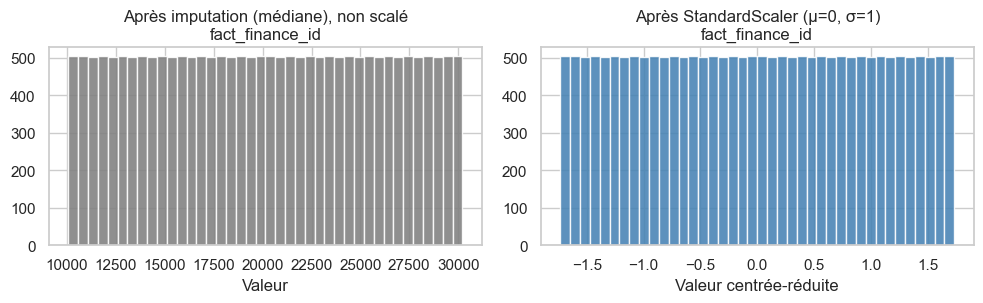

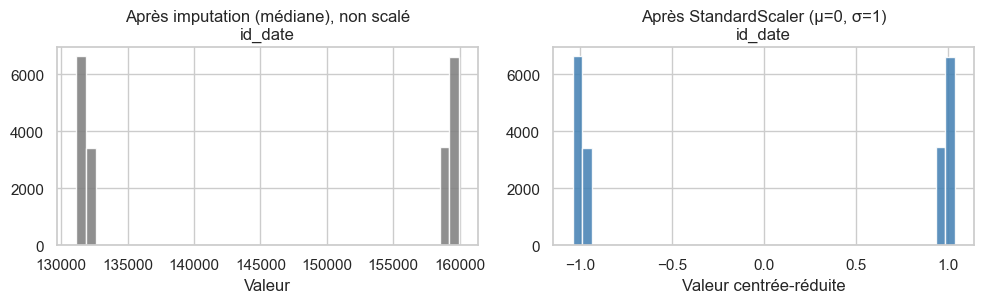


 INTERPRÉTATION — imputation / scaling (colonnes réelles + tables DW)
Jeu large ML `df_ml` / `dw_financial_wide` provient typiquement de :
  • Fait rentabilité : [dbo].[Fact_RentabiliteFinanciere] (alias SQL **f**)
  • Calendrier      : [dbo].[DimDate] (alias **d**) — jointure f.id_date = d.id_date_SK
  • Réservations    : [dbo].[DimReservation] (alias **r**) lorsque la jointure FK ou événement / pont est résolue
(sinon le SELECT peut se limiter à fait + date).

• Jeu : 20142 lignes × 133 colonnes — chaque colonne ci-dessous est standardisée.
• Imputation médiane + StandardScaler / MinMaxScaler : **même liste** que `numeric_feature_list.json`.
  Colonnes (nom Python → table DW) — extrait :
    fact_finance_id                                     [dbo].[Fact_RentabiliteFinanciere]
    id_date                                             [dbo].[Fact_RentabiliteFinanciere]
    id_event                                            [dbo].[Fact_RentabiliteFinanciere]
    id_servicecategory     

In [10]:
# --- Imputation + scaling + exports ---
%matplotlib inline
import sys
for _m in ("ML.dw_lineage", "ML.schema_eventzilla"):
    sys.modules.pop(_m, None)
import matplotlib.pyplot as plt
from ML.schema_eventzilla import infer_column_dw_source, ml_financial_wide_sql_tables_lineage

imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()
X_num = imputer.fit_transform(X_raw)
X_std = scaler.fit_transform(X_num)

np.save(ML_PROCESSED / "X_standardized.npy", X_std)
df_out = pd.DataFrame(X_std, columns=X_raw.columns)
try:
    df_out.to_parquet(ML_PROCESSED / "features_matrix.parquet", index=False)
except Exception:
    df_out.to_csv(ML_PROCESSED / "features_matrix.csv", index=False)

joblib.dump(scaler, ML_PROCESSED / "standard_scaler.joblib")
joblib.dump(imputer, ML_PROCESSED / "median_imputer.joblib")

mm = MinMaxScaler()
X_mm = mm.fit_transform(X_num)
np.save(ML_PROCESSED / "X_minmax.npy", X_mm)
joblib.dump(mm, ML_PROCESSED / "minmax_scaler.joblib")

with open(ML_PROCESSED / "numeric_feature_list.json", "w", encoding="utf-8") as f:
    json.dump(list(X_raw.columns), f, indent=2, ensure_ascii=False)

demo_idx = []
for j, c in enumerate(X_raw.columns):
    col = X_num[:, j]
    if np.nanstd(col) > 1e-12:
        demo_idx.append((j, c))
    if len(demo_idx) >= 2:
        break
for k, (j, cname) in enumerate(demo_idx):
    fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
    axes[0].hist(X_num[:, j], bins=40, color="gray", alpha=0.88, edgecolor="white")
    axes[0].set_title("Après imputation (médiane), non scalé\n" + str(cname)[:48])
    axes[0].set_xlabel("Valeur")
    axes[1].hist(X_std[:, j], bins=40, color="steelblue", alpha=0.88, edgecolor="white")
    axes[1].set_title("Après StandardScaler (μ=0, σ=1)\n" + str(cname)[:48])
    axes[1].set_xlabel("Valeur centrée-réduite")
    plt.tight_layout()
    plt.savefig(ML_PROCESSED / f"A_hist_before_after_{k}.png", dpi=120, bbox_inches="tight")
    plt.show()

print("\n" + "=" * 62)
print(" INTERPRÉTATION — imputation / scaling (colonnes réelles + tables DW)")
print("=" * 62)
print(ml_financial_wide_sql_tables_lineage())
print(f"\n• Jeu : {X_raw.shape[0]} lignes × {X_raw.shape[1]} colonnes — chaque colonne ci-dessous est standardisée.")
_cols = list(X_raw.columns)
print("• Imputation médiane + StandardScaler / MinMaxScaler : **même liste** que `numeric_feature_list.json`.")
print("  Colonnes (nom Python → table DW) — extrait :")
for _ci, _cc in enumerate(_cols[:35]):
    print(f"    {str(_cc)[:50]:50s}  {infer_column_dw_source(_cc)}")
if len(_cols) > 35:
    print(f"    … +{len(_cols) - 35} colonnes (voir A_xraw_column_lineage.json)")
print("\n• Pourquoi StandardScaler : μ≈0, σ≈1 sur **toutes** les colonnes pour comparer échelles (fait vs DimDate vs dummies).")
print("• MinMaxScaler : même périmètre → `X_minmax.npy`.")
nan_tot = int(X_raw.isna().sum().sum())
print(f"\n• NaN totaux avant imputation médiane : {nan_tot}.")
if demo_idx:
    print("• Figures `A_hist_before_after_*.png` (exemples) :")
    for k, (j, cname) in enumerate(demo_idx):
        nmiss = int(X_raw[cname].isna().sum()) if cname in X_raw.columns else 0
        print(
            f"  [{k}] {cname!r} — {nmiss} NaN → médiane | table : {infer_column_dw_source(cname)}"
        )
    print("  → Gauche : échelle brute ; droite : z-score par colonne.")
else:
    print("• Aucun histogramme démo (colonnes à variance nulle uniquement).")
print("• Fichiers : `median_imputer.joblib` + `standard_scaler.joblib` / `minmax_scaler.joblib` pour réappliquer les mêmes règles au scoring.")
print("=" * 62 + "\n")

print("[Imputation] ✅ Terminé. Dossier :", ML_PROCESSED.resolve())
print("📁 Fichiers clés : dw_financial_wide.parquet, X_raw_numeric.npy, X_standardized.npy, X_minmax.npy, features_matrix.*, A_feature_selection_summary.json")
